This course focus on Exponential Smoothing and Holt-Winters

# Libraries and Data

In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [2]:
df = pd.read_csv('Python - Time Series Forecasting/Time Series Analysis/Exponential Smoothing and Holt Winters/weekly_customer_complaints.csv', index_col="week", parse_dates=True)
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [3]:
#Information about the df
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   complaints               261 non-null    object
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 12.2+ KB


# Data Pre-processing

In [4]:
df['complaints'] = df['complaints'].str.replace(",", '').astype(float)

In [5]:
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq=None)

In [6]:
df = df.asfreq("W-Mon")
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq='W-MON')

# Exploratory Data Analysis

In [7]:
df['complaints']

week
2018-01-01    1750.0
2018-01-08    1701.0
2018-01-15    1711.0
2018-01-22    1443.0
2018-01-29    1397.0
               ...  
2022-11-28    4444.0
2022-12-05    4920.0
2022-12-12    5342.0
2022-12-19    3868.0
2022-12-26    3607.0
Freq: W-MON, Name: complaints, Length: 261, dtype: float64

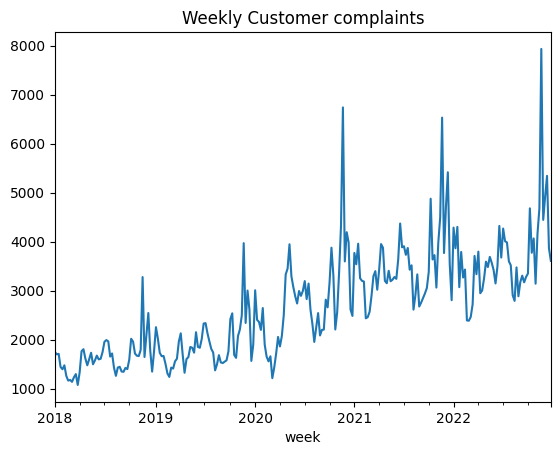

In [8]:
# Plot the Weekly Customer complaints
df['complaints'].plot(title="Weekly Customer complaints")
plt.show()

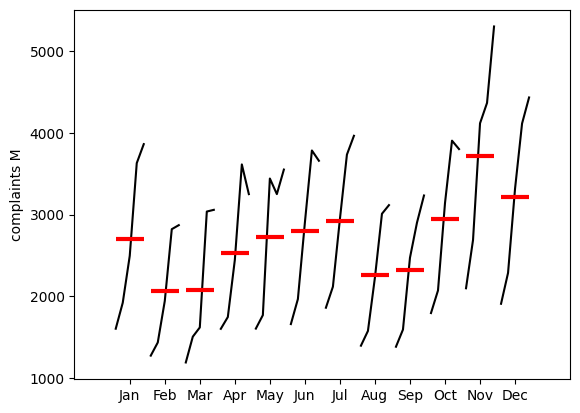

In [9]:
# Plotting the monthly seasonality
month_plot(df['complaints'].resample('ME').mean(),
           ylabel = 'complaints M')
plt.show()

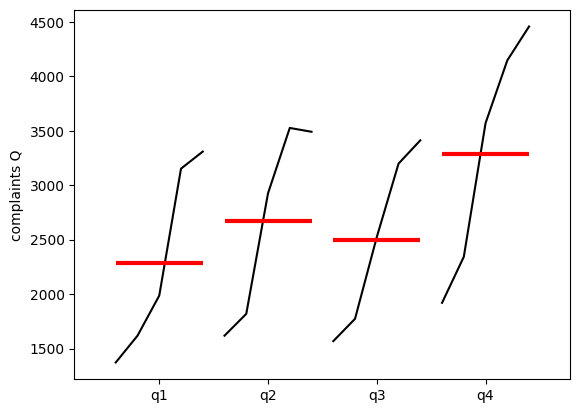

In [10]:
# Plotting the quarterly seasonality
quarter_plot(df['complaints'].resample('QE').mean(),
           ylabel = 'complaints Q')
plt.show()

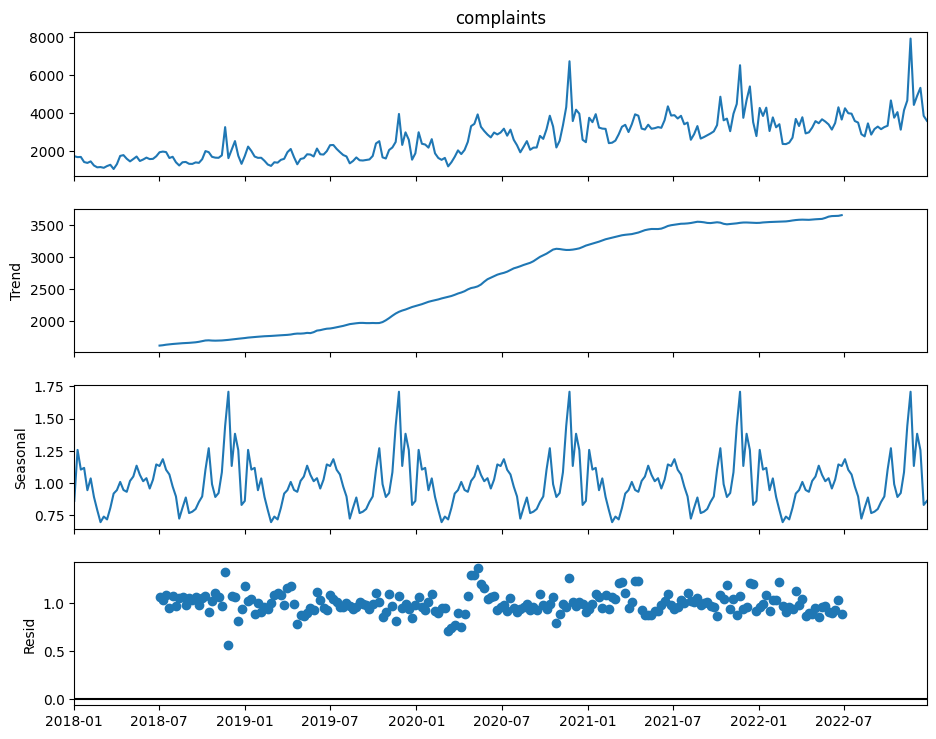

In [11]:
# Seasonal Decomposition Plots for Bitcoin Data
decomposition = seasonal_decompose(df['complaints'],
                                   model = 'mul',
                                   period = 52)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

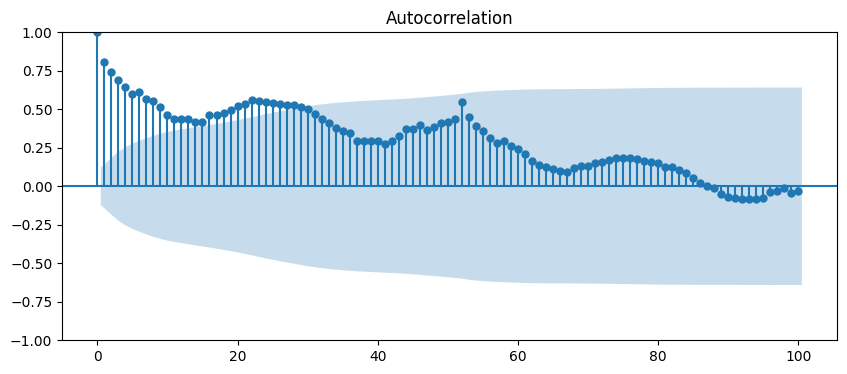

In [12]:
# Plot the autocorrelation (ACF)
fig, ax = plt.subplots(figsize = (10,4))
plot_acf(df['complaints'], lags = 100, ax = ax)
plt.show()

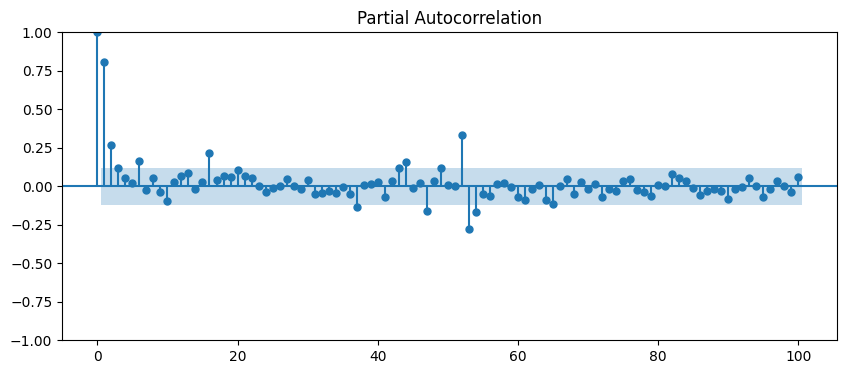

In [13]:
# Plot the partial autocorrelation (PACF)
fig, ax = plt.subplots(figsize = (10,4))
plot_pacf(df['complaints'], lags = 100, ax = ax)
plt.show()

# Training and test 

## Goal : to predict the next quarter (13 weeks)

In [14]:
# Training and Test Split
periods = 13
train, test = df.iloc[:-13,0], df.iloc[-13:,0]

In [15]:
train

week
2018-01-01    1750.0
2018-01-08    1701.0
2018-01-15    1711.0
2018-01-22    1443.0
2018-01-29    1397.0
               ...  
2022-08-29    2885.0
2022-09-05    3177.0
2022-09-12    3306.0
2022-09-19    3170.0
2022-09-26    3279.0
Freq: W-MON, Name: complaints, Length: 248, dtype: float64

In [16]:
test

week
2022-10-03    3350.0
2022-10-10    4679.0
2022-10-17    3773.0
2022-10-24    4065.0
2022-10-31    3142.0
2022-11-07    4164.0
2022-11-14    4677.0
2022-11-21    7931.0
2022-11-28    4444.0
2022-12-05    4920.0
2022-12-12    5342.0
2022-12-19    3868.0
2022-12-26    3607.0
Freq: W-MON, Name: complaints, dtype: float64

# Simple Exponential Smoothing

In [30]:
# Simple Exponential Smoothing Model and Predictions
model_simple = ExponentialSmoothing(train).fit()
prediction_simple = model_simple.forecast(len(test))

In [31]:
prediction_simple

2022-10-03    3236.62261
2022-10-10    3236.62261
2022-10-17    3236.62261
2022-10-24    3236.62261
2022-10-31    3236.62261
2022-11-07    3236.62261
2022-11-14    3236.62261
2022-11-21    3236.62261
2022-11-28    3236.62261
2022-12-05    3236.62261
2022-12-12    3236.62261
2022-12-19    3236.62261
2022-12-26    3236.62261
Freq: W-MON, dtype: float64

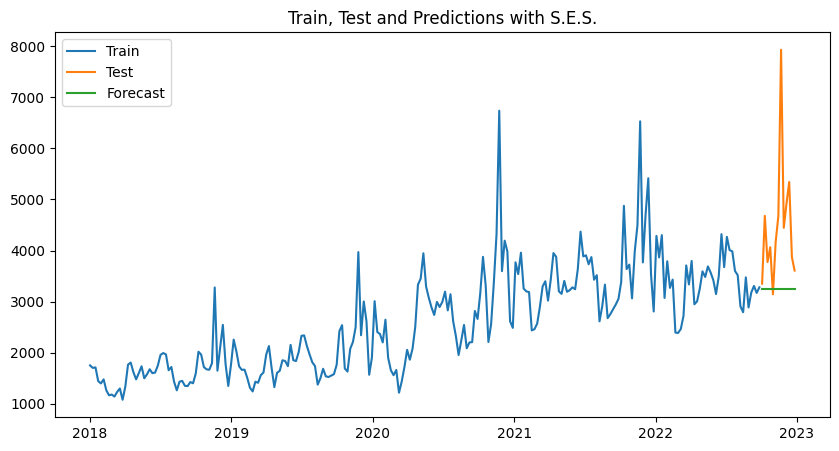

In [18]:
# Plot training, test, and forecasts
plt.figure(figsize=(10,5))
plt.plot(train, label = 'Train')
plt.plot(test,  label = 'Test')
plt.plot(prediction_simple,  label = 'Forecast')
plt.title('Train, Test and Predictions with S.E.S.')
plt.legend()
plt.show()

# Double Exponential Smoothing

In [33]:
# Double Exponential Smoothing Model and Predictions
model_double = ExponentialSmoothing(train, trend = "add", seasonal = None).fit()
prediction_double = model_double.forecast(len(test))
prediction_double

2022-10-03    3234.055970
2022-10-10    3232.618242
2022-10-17    3231.180514
2022-10-24    3229.742786
2022-10-31    3228.305058
2022-11-07    3226.867330
2022-11-14    3225.429602
2022-11-21    3223.991874
2022-11-28    3222.554146
2022-12-05    3221.116418
2022-12-12    3219.678690
2022-12-19    3218.240962
2022-12-26    3216.803234
Freq: W-MON, dtype: float64

The data looks horizontal, but we can see that the values decrease over time.

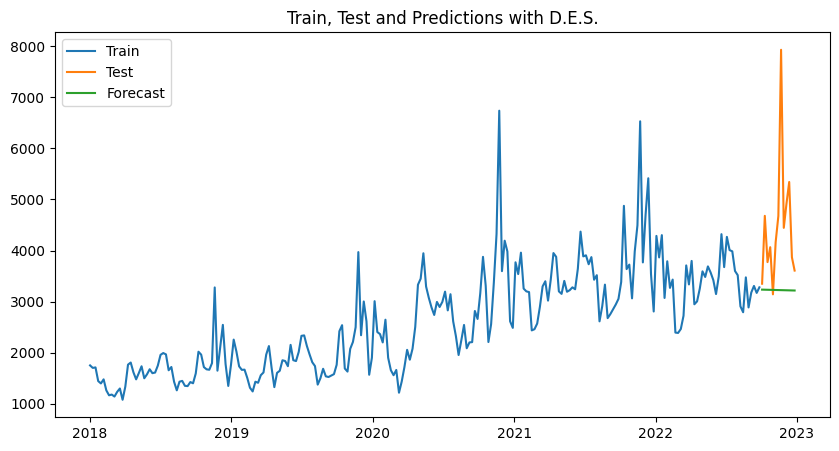

In [28]:
# Plot training, test, and forecasts
plt.figure(figsize=(10,5))
plt.plot(train, label = 'Train')
plt.plot(test,  label = 'Test')
plt.plot(prediction_double,  label = 'Forecast')
plt.title('Train, Test and Predictions with D.E.S.')
plt.legend()
plt.show()

# Triple Exponential Smoothing (Holt-Winters method)

In [34]:
# Triple Exponential Smoothing Model and Predictions
model_triple = ExponentialSmoothing(train, trend = "add", seasonal='mul', seasonal_periods=52).fit()
prediction_triple = model_triple.forecast(len(test))
prediction_triple

2022-10-03    4044.509324
2022-10-10    5061.907922
2022-10-17    3932.923786
2022-10-24    3546.606607
2022-10-31    3440.942096
2022-11-07    4269.876081
2022-11-14    5365.888280
2022-11-21    7312.160363
2022-11-28    4350.231030
2022-12-05    5316.764683
2022-12-12    5284.083803
2022-12-19    3450.680163
2022-12-26    3291.937790
Freq: W-MON, dtype: float64

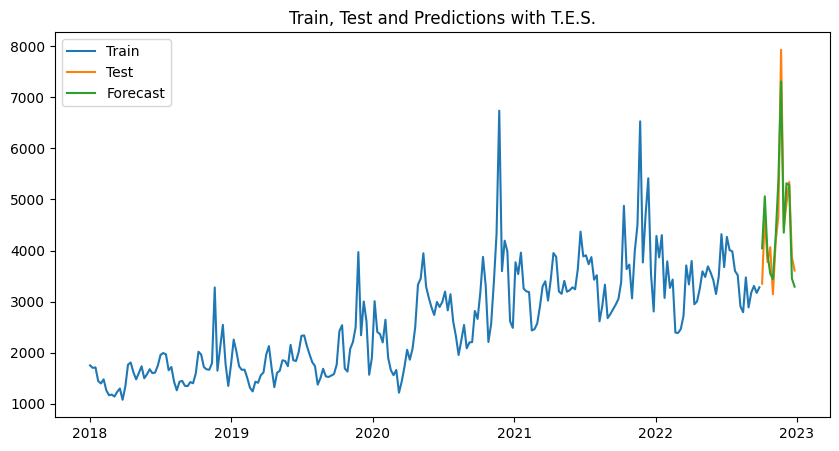

In [35]:
# Plot training, test, and forecasts
plt.figure(figsize=(10,5))
plt.plot(train, label = 'Train')
plt.plot(test,  label = 'Test')
plt.plot(prediction_triple,  label = 'Forecast')
plt.title('Train, Test and Predictions with T.E.S.')
plt.legend()
plt.show()

# Model Assessment

In [19]:
# Function to assess model and visualize output
def model_assessment(train, test, predictions, chart_title):
  # Plot training, test, and forecasts
  plt.figure(figsize = (10,4))
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()

  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  rmse = mean_squared_error(test, predictions, squared = False)
  mape = mean_absolute_percentage_error(test, predictions)

  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")

model_assessment(train['2022-06':], test, predictions_triple, "Holt-Winters")

NameError: name 'predictions_triple' is not defined

# Predicting the future

In [ ]:
# Function to plot the future
def plot_future(y, forecast, title):
  # Plot training and forecasts
  plt.figure(figsize = (10,4))
  plt.plot(y, label = 'Train')
  plt.plot(forecast, label = "Forecast")
  plt.title(f"Train and Forecast with {title}")
  plt.legend()
  plt.show()